# K-Means Workflow


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

```{contents}
:local:
:depth: 2
```


## K-means in a nutshell

K-means partitions the data into "k" groups by minimizing the **within-cluster sum of squares**. It alternates between two steps until convergence:

1. **Assign** each point to the nearest cluster center.
2. **Update** each center to be the mean of its assigned points.

This process is fast and simple, but it assumes clusters are roughly spherical and similar in size.


In [2]:
from sklearn.datasets import make_blobs

## Create Some Data


`make_blobs` generates synthetic Gaussian clusters for quick experiments. It returns the feature matrix and the cluster labels used to create the points. Because we generate the data ourselves, we know which group each point came from, so we can check whether k-means recovers those groups. Real data come without these labels; the next section clusters a customer data set.


In [3]:
# Create Data
data = make_blobs(n_samples=200, n_features=2, 
                           centers=4, cluster_std=1.8,random_state=101)

## Visualize Data

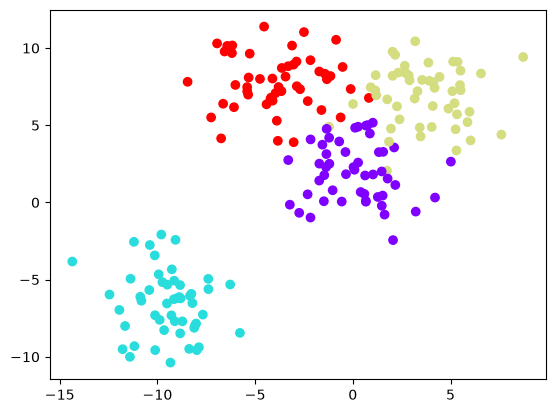

In [4]:
plt.scatter(data[0][:,0],data[0][:,1],c=data[1],cmap='rainbow')

## Creating the Clusters

In [5]:
from sklearn.cluster import KMeans

K-means starts from randomly placed centers, so different runs can end in different clusters. `n_init=10` runs the algorithm 10 times from different starting centers and keeps the best result, and `random_state` fixes the random starts so that the result is the same every time the page is built.

In [6]:
kmeans = KMeans(n_clusters=4, n_init=10, random_state=101)

In [7]:
kmeans.fit(data[0])

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",101
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 2)","[[-9

In [8]:
kmeans.cluster_centers_

array([[-9.46941837, -6.56081545],
       [-0.0123077 ,  2.13407664],
       [ 3.71749226,  7.01388735],
       [-4.13591321,  7.95389851]])

In [9]:
kmeans.labels_

array([3, 2, 1, 2, 2, 0, 2, 1, 2, 1, 3, 1, 2, 2, 3, 1, 2, 1, 0, 3, 0, 1,
       1, 0, 3, 0, 0, 1, 2, 2, 3, 0, 2, 1, 1, 3, 0, 0, 0, 1, 0, 3, 3, 3,
       1, 2, 3, 1, 0, 1, 1, 3, 2, 1, 0, 3, 1, 1, 3, 2, 0, 2, 0, 3, 2, 1,
       0, 2, 2, 0, 2, 1, 0, 1, 0, 2, 2, 1, 3, 1, 1, 0, 2, 0, 1, 1, 1, 3,
       1, 0, 0, 0, 0, 1, 1, 0, 2, 3, 0, 2, 1, 0, 1, 1, 2, 1, 0, 2, 0, 0,
       2, 3, 3, 2, 0, 2, 3, 3, 2, 3, 1, 3, 1, 3, 1, 2, 3, 1, 0, 3, 3, 3,
       1, 0, 0, 3, 2, 3, 2, 1, 0, 2, 0, 3, 3, 2, 1, 0, 3, 3, 3, 3, 1, 2,
       1, 3, 2, 2, 2, 1, 2, 1, 1, 3, 0, 3, 1, 2, 3, 1, 2, 1, 3, 2, 1, 3,
       2, 2, 0, 2, 3, 0, 0, 3, 0, 0, 0, 0, 0, 1, 0, 2, 2, 3, 0, 1, 2, 2,
       0, 1], dtype=int32)

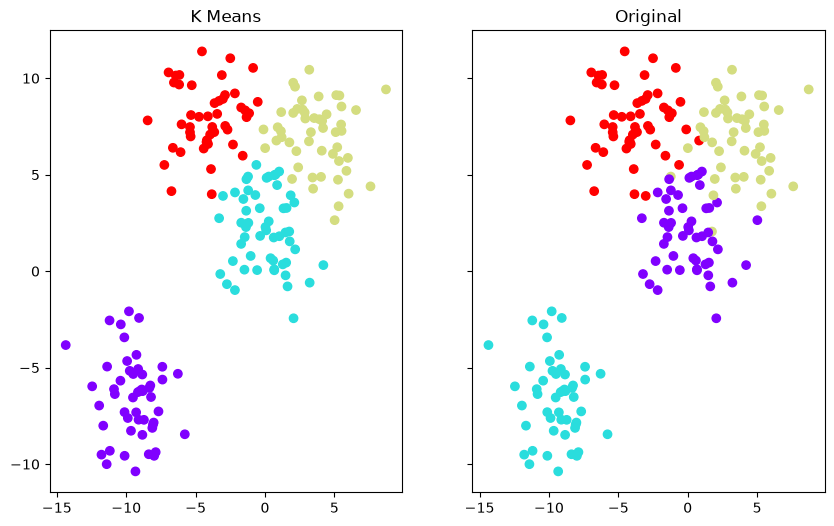

In [10]:
f, (ax1, ax2) = plt.subplots(1, 2, sharey=True,figsize=(10,6))
ax1.set_title('K Means')
ax1.scatter(data[0][:,0],data[0][:,1],c=kmeans.labels_,cmap='rainbow')
ax2.set_title("Original")
ax2.scatter(data[0][:,0],data[0][:,1],c=data[1],cmap='rainbow')

The two plots mostly agree, except where the original groups overlap. The colors need not match: k-means numbers its clusters in whatever order it finds them, so a group that is cluster 2 in the original labels may be cluster 0 in the k-means result. Cluster numbers are names, not rankings.


## Section Practice

Use this short exercise to check the main workflow from this section.


In [11]:
### Exercise: Practice K-Means Workflow
# Run one round of k-means by hand on six customers' monthly spend (one feature).
#   1. Assign each value to the nearer of the two centers (0 or 1).
#   2. Update each center to the mean of the values assigned to it.
# Print exactly:
# Assignments: [0, 0, 0, 1, 1, 1]
# New centers: [22.0, 71.0]
spend = [12, 20, 34, 58, 70, 85]
centers = [20, 60]
### Your code starts here




### Your code ends here


In [12]:
### Solution
spend = [12, 20, 34, 58, 70, 85]
centers = [20, 60]

assignments = []
for value in spend:
    if abs(value - centers[0]) <= abs(value - centers[1]):
        assignments.append(0)
    else:
        assignments.append(1)

new_centers = []
for cluster in [0, 1]:
    members = [v for v, a in zip(spend, assignments) if a == cluster]
    new_centers.append(sum(members) / len(members))

print('Assignments:', assignments)
print('New centers:', new_centers)


Assignments: [0, 0, 0, 1, 1, 1]
New centers: [22.0, 71.0]


In [13]:
### Exercise: Section Practice 1
# book-rule-sparse-practice
# A manager wants a short check on the chapter section named below.
# Create a list named steps with three actions: identify decision, choose metric, explain result.
# Print exactly these three lines, using the existing section_focus value:
# Section: K-means in a nutshell
# Steps: 3
# First step: identify decision
section_focus = 'K-means in a nutshell'

### Your code starts here.

### Your code ends here.


In [14]:
section_focus = 'K-means in a nutshell'
steps = ["identify decision", "choose metric", "explain result"]
print("Section:", section_focus)
print("Steps:", len(steps))
print("First step:", steps[0])


Section: K-means in a nutshell
Steps: 3
First step: identify decision


In [15]:
### Exercise: Section Practice 2
# book-rule-sparse-practice
# The chapter uses the section headings to organize related ideas.
# Store the three provided terms in a list named representative_terms.
# Print exactly these two lines:
# Terms: K-means, nutshell, Create
# Term count: 3
provided_terms = ['K-means', 'nutshell', 'Create']

### Your code starts here.

### Your code ends here.


In [16]:
representative_terms = ['K-means', 'nutshell', 'Create']
print("Terms:", ", ".join(representative_terms))
print("Term count:", len(representative_terms))


Terms: K-means, nutshell, Create
Term count: 3
